# Intrusion Detection System — Ensemble Model
### Random Forest + XGBoost + Neural Network (Soft Voting)
**Datasets:** CIC-IDS2017 (MachineLearningCVE) + UNSW-NB15  
**Task:** Binary classification (Normal vs Attack) + Multi-class attack category detection

## 1. Imports & Setup

In [43]:
import os, warnings, time
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
OUTPUT_DIR   = 'Ensemble_Output'
print('Setup complete.')

Setup complete.


## 2. Dataset Merging — CIC-IDS2017 + UNSW-NB15

Both datasets cover network intrusion traffic but use different schemas:
- **CIC-IDS2017**: 80 flow-based features, labels like `BENIGN`, `DDoS`, `PortScan`, etc.
- **UNSW-NB15**: 43 features, binary label + attack category column.

We map both to a **unified 41-feature schema** covering packet counts, byte counts, flow rates, TCP flags, window sizes, and idle times.

In [44]:
import glob

CIC_COL_MAP = {
    'Destination Port':'dst_port',' Destination Port':'dst_port',
    ' Flow Duration':'duration',' Total Fwd Packets':'src_pkts',
    ' Total Backward Packets':'dst_pkts',' Total Length of Fwd Packets':'src_bytes',
    ' Total Length of Bwd Packets':'dst_bytes',' Flow Bytes/s':'flow_bytes_per_sec',
    ' Flow Packets/s':'flow_pkts_per_sec',' Flow IAT Mean':'flow_iat_mean',
    ' Flow IAT Std':'flow_iat_std',' Flow IAT Max':'flow_iat_max',' Flow IAT Min':'flow_iat_min',
    ' Fwd IAT Mean':'src_iat_mean',' Fwd IAT Std':'src_iat_std',
    ' Fwd IAT Max':'src_iat_max',' Fwd IAT Min':'src_iat_min',
    ' Bwd IAT Mean':'dst_iat_mean',' Bwd IAT Std':'dst_iat_std',
    ' Bwd IAT Max':'dst_iat_max',' Bwd IAT Min':'dst_iat_min',
    ' Fwd PSH Flags':'src_psh_flags',' Bwd PSH Flags':'dst_psh_flags',
    ' Fwd URG Flags':'src_urg_flags',' Bwd URG Flags':'dst_urg_flags',
    ' Fwd Header Length':'src_header_len',' Bwd Header Length':'dst_header_len',
    ' Fwd Packets/s':'src_pkts_per_sec',' Bwd Packets/s':'dst_pkts_per_sec',
    ' Min Packet Length':'pkt_len_min',' Max Packet Length':'pkt_len_max',
    ' Packet Length Mean':'pkt_len_mean',' Packet Length Std':'pkt_len_std',
    ' Packet Length Variance':'pkt_len_var',' FIN Flag Count':'fin_flag_cnt',
    ' SYN Flag Count':'syn_flag_cnt',' RST Flag Count':'rst_flag_cnt',
    ' PSH Flag Count':'psh_flag_cnt',' ACK Flag Count':'ack_flag_cnt',
    ' URG Flag Count':'urg_flag_cnt',' CWE Flag Count':'cwe_flag_cnt',
    ' ECE Flag Count':'ece_flag_cnt',' Down/Up Ratio':'down_up_ratio',
    ' Average Packet Size':'avg_pkt_size',' Avg Fwd Segment Size':'avg_src_seg_size',
    ' Avg Bwd Segment Size':'avg_dst_seg_size',' Init_Win_bytes_forward':'src_win_bytes',
    ' Init_Win_bytes_backward':'dst_win_bytes',' act_data_pkt_fwd':'src_act_data_pkts',
    ' min_seg_size_forward':'src_seg_size_min',' Idle Mean':'idle_mean',
    ' Idle Std':'idle_std',' Idle Max':'idle_max',' Idle Min':'idle_min',
    ' Label':'_raw_label',
}
CIC_ATTACK_MAP = {
    'BENIGN':'Normal','DDoS':'DoS','DoS Hulk':'DoS','DoS GoldenEye':'DoS',
    'DoS slowloris':'DoS','DoS Slowhttptest':'DoS','Heartbleed':'Exploits',
    'PortScan':'Reconnaissance','FTP-Patator':'Brute Force','SSH-Patator':'Brute Force',
    'Bot':'Backdoor','Web Attack \x96 Brute Force':'Brute Force',
    'Web Attack \x96 XSS':'Web Attack','Web Attack \x96 Sql Injection':'Web Attack',
    'Web Attack \u2013 Brute Force':'Brute Force','Web Attack \u2013 XSS':'Web Attack',
    'Web Attack \u2013 Sql Injection':'Web Attack','Infiltration':'Reconnaissance',
}
UNSW_COL_MAP = {
    'dur':'duration','spkts':'src_pkts','dpkts':'dst_pkts',
    'sbytes':'src_bytes','dbytes':'dst_bytes','rate':'flow_pkts_per_sec',
    'sload':'flow_bytes_per_sec','sinpkt':'src_iat_mean','dinpkt':'dst_iat_mean',
    'sjit':'src_iat_std','djit':'dst_iat_std','swin':'src_win_bytes','dwin':'dst_win_bytes',
    'smean':'avg_src_seg_size','dmean':'avg_dst_seg_size','sloss':'src_psh_flags',
    'dloss':'dst_psh_flags','tcprtt':'flow_iat_mean','synack':'syn_flag_cnt',
    'ackdat':'ack_flag_cnt','attack_cat':'_raw_attack_cat','label':'_raw_label',
}
UNSW_ATTACK_MAP = {
    'Normal':'Normal','Backdoor':'Backdoor','Analysis':'Reconnaissance',
    'Fuzzers':'Fuzzers','Shellcode':'Exploits','Reconnaissance':'Reconnaissance',
    'Exploits':'Exploits','DoS':'DoS','Generic':'Generic','Worms':'Worms',
}
FEATURE_COLS = [
    'duration','src_pkts','dst_pkts','src_bytes','dst_bytes',
    'flow_bytes_per_sec','flow_pkts_per_sec','flow_iat_mean',
    'src_iat_mean','dst_iat_mean','src_iat_std','dst_iat_std',
    'src_psh_flags','dst_psh_flags','src_urg_flags','dst_urg_flags',
    'src_header_len','dst_header_len','src_pkts_per_sec','dst_pkts_per_sec',
    'pkt_len_min','pkt_len_max','pkt_len_mean','pkt_len_std','pkt_len_var',
    'fin_flag_cnt','syn_flag_cnt','rst_flag_cnt','psh_flag_cnt',
    'ack_flag_cnt','urg_flag_cnt','down_up_ratio','avg_pkt_size',
    'avg_src_seg_size','avg_dst_seg_size','src_win_bytes','dst_win_bytes',
    'idle_mean','idle_std','idle_max','idle_min',
]

# ── Load CIC files ────────────────────────────────────────────────────────────
cic_files = glob.glob('MachineLearningCVE/*.csv')
cic_frames = []
for f in cic_files:
    df = pd.read_csv(f, low_memory=False)
    df.columns = df.columns.str.strip()
    col_map = {k.strip(): v for k, v in CIC_COL_MAP.items()}
    df.rename(columns=col_map, inplace=True)
    cic_frames.append(df)
cic = pd.concat(cic_frames, ignore_index=True)
cic['_raw_label'] = cic['_raw_label'].astype(str).str.strip()
cic['attack_category'] = cic['_raw_label'].map(CIC_ATTACK_MAP).fillna('Unknown')
cic['label'] = (cic['attack_category'] != 'Normal').astype(int)
cic['source'] = 'CIC-IDS2017'

# ── Load UNSW files ───────────────────────────────────────────────────────────
unsw = pd.concat([
    pd.read_csv('UNSW CSV/Training and Testing Sets/UNSW_NB15_training-set.csv', low_memory=False),
    pd.read_csv('UNSW CSV/Training and Testing Sets/UNSW_NB15_testing-set.csv',  low_memory=False),
], ignore_index=True)
unsw.rename(columns=UNSW_COL_MAP, inplace=True)
unsw['_raw_attack_cat'] = unsw['_raw_attack_cat'].astype(str).str.strip()
unsw['attack_category'] = unsw['_raw_attack_cat'].map(UNSW_ATTACK_MAP).fillna('Unknown')
unsw['label'] = unsw['_raw_label'].astype(int)
unsw['source'] = 'UNSW-NB15'

# ── Merge ─────────────────────────────────────────────────────────────────────
all_cols = ['source'] + FEATURE_COLS + ['attack_category', 'label']
for df_, name in [(cic, 'CIC'), (unsw, 'UNSW')]:
    for col in all_cols:
        if col not in df_.columns:
            df_[col] = 0

merged = pd.concat([cic[all_cols], unsw[all_cols]], ignore_index=True)
num_cols = FEATURE_COLS
merged[num_cols] = merged[num_cols].apply(pd.to_numeric, errors='coerce')
merged[num_cols] = merged[num_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
before = len(merged)
merged.drop_duplicates(inplace=True)
print(f'CIC rows   : {len(cic):,}')
print(f'UNSW rows  : {len(unsw):,}')
print(f'Duplicates removed: {before - len(merged):,}')
print(f'Final merged shape : {merged.shape}')

CIC rows   : 2,830,743
UNSW rows  : 257,673
Duplicates removed: 725,171
Final merged shape : (2363245, 44)


## 3. Exploratory Data Analysis

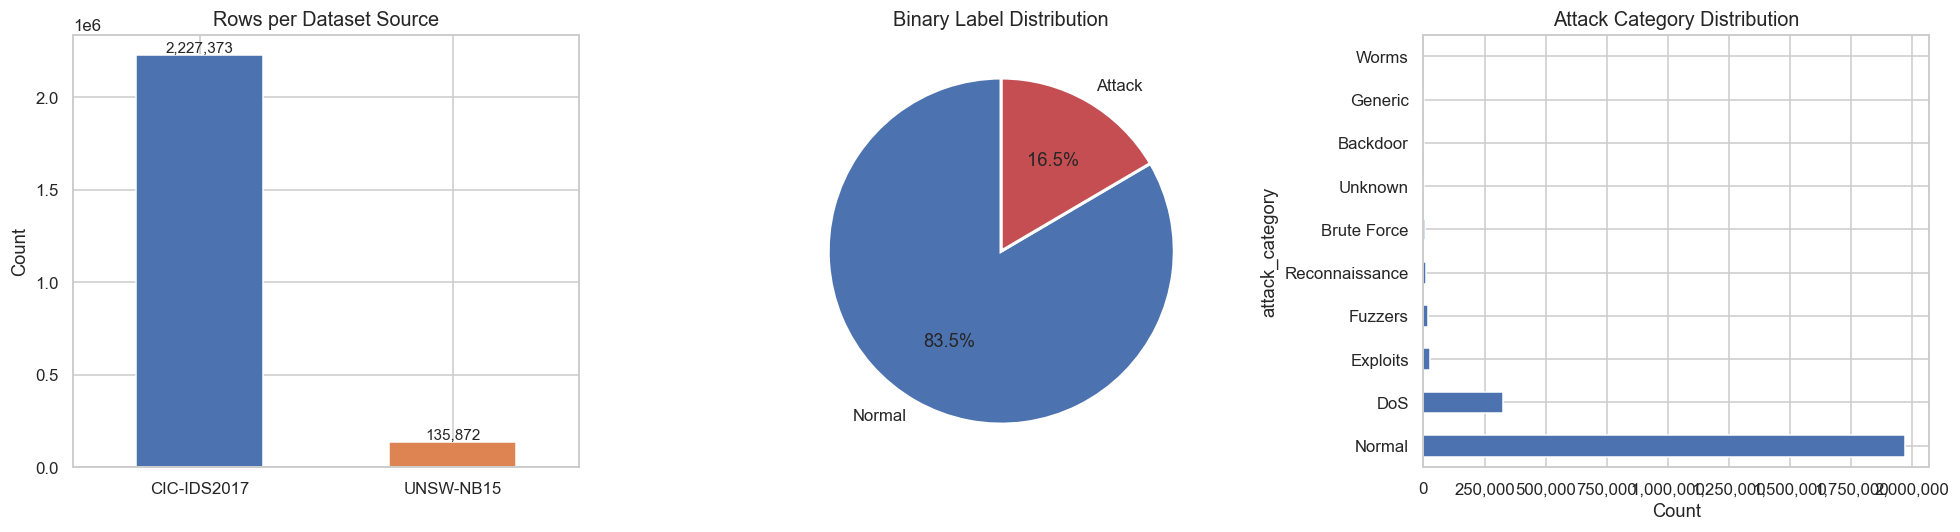

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Source distribution
merged['source'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'], edgecolor='white')
axes[0].set_title('Rows per Dataset Source', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Binary label
lbl_counts = merged['label'].value_counts().sort_index()
axes[1].pie(lbl_counts, labels=['Normal','Attack'], autopct='%1.1f%%',
            colors=['#4C72B0','#C44E52'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Binary Label Distribution', fontsize=13)

# Attack category
cat_counts = merged['attack_category'].value_counts()
cat_counts.plot(kind='barh', ax=axes[2], color='#4C72B0', edgecolor='white')
axes[2].set_title('Attack Category Distribution', fontsize=13)
axes[2].set_xlabel('Count')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_distributions.png'), bbox_inches='tight')
plt.show()

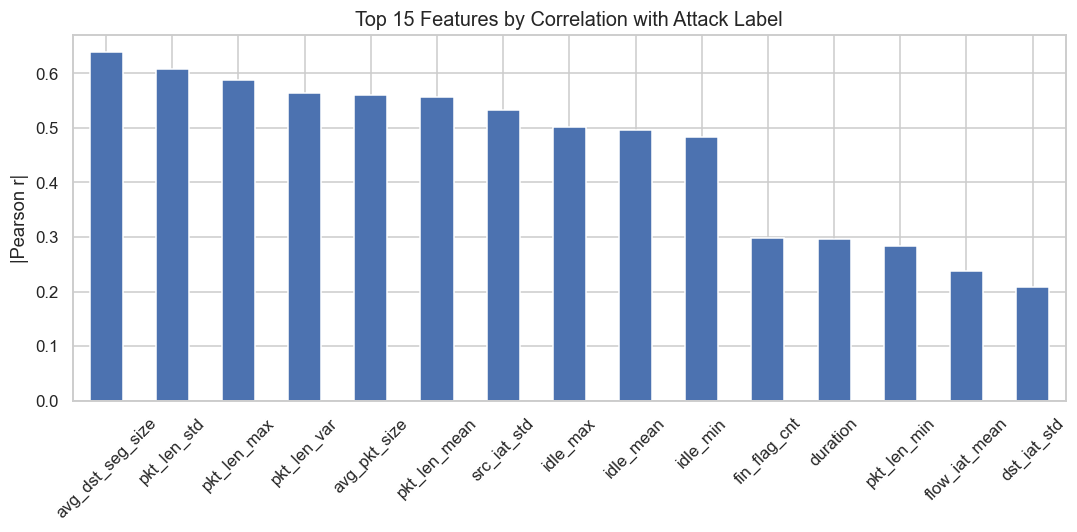

In [46]:
# Top-15 feature correlations with binary label
corr = merged[FEATURE_COLS + ['label']].corr()['label'].drop('label').abs().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
corr.head(15).plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Top 15 Features by Correlation with Attack Label', fontsize=13)
ax.set_ylabel('|Pearson r|')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_feature_correlation.png'), bbox_inches='tight')
plt.show()

In [47]:
print('=== Dataset Summary ===')
print(f'Total samples  : {len(merged):,}')
print(f'Features       : {len(FEATURE_COLS)}')
print(f'Normal traffic : {(merged["label"]==0).sum():,} ({(merged["label"]==0).mean()*100:.1f}%)')
print(f'Attack traffic : {(merged["label"]==1).sum():,} ({(merged["label"]==1).mean()*100:.1f}%)')
print()
print('Attack categories:')
print(merged['attack_category'].value_counts().to_string())
print()
merged[FEATURE_COLS].describe().T[['mean','std','min','max']].round(2)

=== Dataset Summary ===
Total samples  : 2,363,245
Features       : 41
Normal traffic : 1,972,314 (83.5%)
Attack traffic : 390,931 (16.5%)

Attack categories:
attack_category
Normal            1972314
DoS                324197
Exploits            27118
Fuzzers             16771
Reconnaissance       9569
Brute Force          7484
Unknown              2143
Backdoor             2132
Generic              1353
Worms                 164



,mean,std,min,max
duration,17691584.30,36113340.46,-1.300000e+01,1.200000e+08
src_pkts,12.72,821.66,1.000000e+00,2.197590e+05
dst_pkts,14.20,1092.18,0.000000e+00,2.919220e+05
src_bytes,1529.82,57634.65,0.000000e+00,1.435577e+07
dst_bytes,20885.49,2477270.64,0.000000e+00,6.554530e+08
flow_bytes_per_sec,1785725.96,42572274.11,-2.610000e+08,5.988000e+09
flow_pkts_per_sec,16086.81,106250.37,-2.000000e+06,4.000000e+06
flow_iat_mean,1540417.43,4814644.97,-1.300000e+01,1.200000e+08
src_iat_mean,3107950.19,10290364.03,0.000000e+00,1.200000e+08
dst_iat_mean,2157213.79,9659478.11,0.000000e+00,1.200000e+08


## 4. Data Preparation & Train/Test Split

In [48]:
X = merged[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0)
y_bin = merged['label'].astype(int).values

le = joblib.load(os.path.join(OUTPUT_DIR, 'label_encoder.pkl'))
y_multi = le.transform(merged['attack_category'].astype(str))

X_train, X_test, yb_tr, yb_te, ym_tr, ym_te = train_test_split(
    X, y_bin, y_multi, test_size=0.20,
    random_state=RANDOM_STATE, stratify=y_bin
)

scaler = joblib.load(os.path.join(OUTPUT_DIR, 'scaler.pkl'))
X_tr_sc = scaler.transform(X_train)
X_te_sc = scaler.transform(X_test)

print(f'Train set : {len(X_train):,} samples')
print(f'Test set  : {len(X_test):,} samples')
print(f'Classes   : {list(le.classes_)}')

Train set : 1,890,596 samples
Test set  : 472,649 samples
Classes   : ['Backdoor', 'Brute Force', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Unknown', 'Worms']


## 5. Load Pre-Trained Models
Models were trained on the full 2.3M-row dataset and saved as checkpoints.

In [49]:
rf_bin  = joblib.load(os.path.join(OUTPUT_DIR, 'rf_binary.pkl'))
xgb_bin = joblib.load(os.path.join(OUTPUT_DIR, 'xgb_binary.pkl'))
mlp_bin = joblib.load(os.path.join(OUTPUT_DIR, 'mlp_binary.pkl'))
rf_mc   = joblib.load(os.path.join(OUTPUT_DIR, 'rf_multiclass.pkl'))
xgb_mc  = joblib.load(os.path.join(OUTPUT_DIR, 'xgb_multiclass.pkl'))
mlp_mc  = joblib.load(os.path.join(OUTPUT_DIR, 'mlp_multiclass.pkl'))
print('All 6 models loaded successfully.')
print(f'  RF  binary   : {rf_bin.n_estimators} trees, max_depth={rf_bin.max_depth}')
print(f'  XGB binary   : {xgb_bin.n_estimators} trees, max_depth={xgb_bin.max_depth}')
print(f'  MLP binary   : layers={mlp_bin.hidden_layer_sizes}')

All 6 models loaded successfully.
  RF  binary   : 200 trees, max_depth=20
  XGB binary   : 300 trees, max_depth=8
  MLP binary   : layers=(256, 128, 64)


## 6. Binary Classification — Individual Model Evaluation

In [50]:
p_rf  = rf_bin.predict_proba(X_test)
p_xgb = xgb_bin.predict_proba(X_test)
p_mlp = mlp_bin.predict_proba(X_te_sc)

results = {}
for name, proba in [('Random Forest', p_rf), ('XGBoost', p_xgb), ('Neural Network', p_mlp)]:
    pred = (proba[:, 1] >= 0.5).astype(int)
    results[name] = {
        'Accuracy': accuracy_score(yb_te, pred),
        'F1 (weighted)': f1_score(yb_te, pred, average='weighted'),
        'AUC-ROC': roc_auc_score(yb_te, proba[:, 1]),
    }

# Ensemble
ens_prob = (p_rf[:,1] + p_xgb[:,1] + p_mlp[:,1]) / 3.0
ens_pred = (ens_prob >= 0.5).astype(int)
results['Ensemble (RF+XGB+MLP)'] = {
    'Accuracy': accuracy_score(yb_te, ens_pred),
    'F1 (weighted)': f1_score(yb_te, ens_pred, average='weighted'),
    'AUC-ROC': roc_auc_score(yb_te, ens_prob),
}

results_df = pd.DataFrame(results).T.round(4)
results_df.index.name = 'Model'
print('Binary Classification Results:')
print(results_df.to_string())

Binary Classification Results:
                       Accuracy  F1 (weighted)  AUC-ROC
Model                                                  
Random Forest            0.9885         0.9886   0.9996
XGBoost                  0.9930         0.9930   0.9997
Neural Network           0.9888         0.9888   0.9991
Ensemble (RF+XGB+MLP)    0.9916         0.9917   0.9997


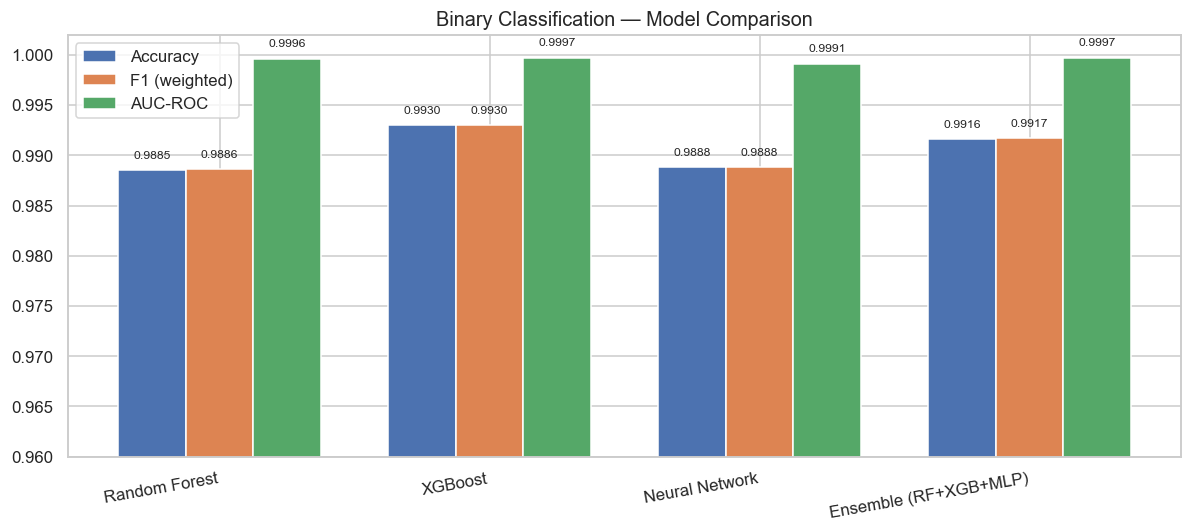

In [51]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(results_df))
w = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']
for i, (metric, color) in enumerate(zip(['Accuracy','F1 (weighted)','AUC-ROC'], colors)):
    bars = ax.bar(x + i*w, results_df[metric], w, label=metric, color=color, edgecolor='white')
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
                f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x + w)
ax.set_xticklabels(results_df.index, rotation=10, ha='right')
ax.set_ylim(0.96, 1.002)
ax.set_title('Binary Classification — Model Comparison', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'binary_model_comparison.png'), bbox_inches='tight')
plt.show()

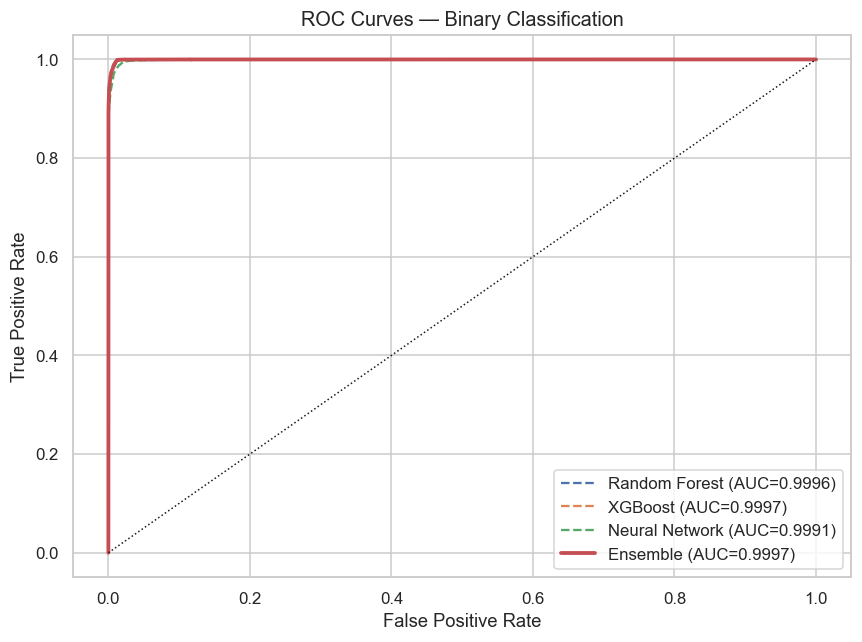

In [52]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba, color in [
    ('Random Forest',   p_rf[:,1],  '#4C72B0'),
    ('XGBoost',         p_xgb[:,1], '#DD8452'),
    ('Neural Network',  p_mlp[:,1], '#55A868'),
    ('Ensemble',        ens_prob,   '#C44E52'),
]:
    fpr, tpr, _ = roc_curve(yb_te, proba)
    auc = roc_auc_score(yb_te, proba)
    lw = 2.5 if name == 'Ensemble' else 1.5
    ls = '-' if name == 'Ensemble' else '--'
    ax.plot(fpr, tpr, color=color, lw=lw, ls=ls, label=f'{name} (AUC={auc:.4f})')
ax.plot([0,1],[0,1],'k:',lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Binary Classification', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), bbox_inches='tight')
plt.show()

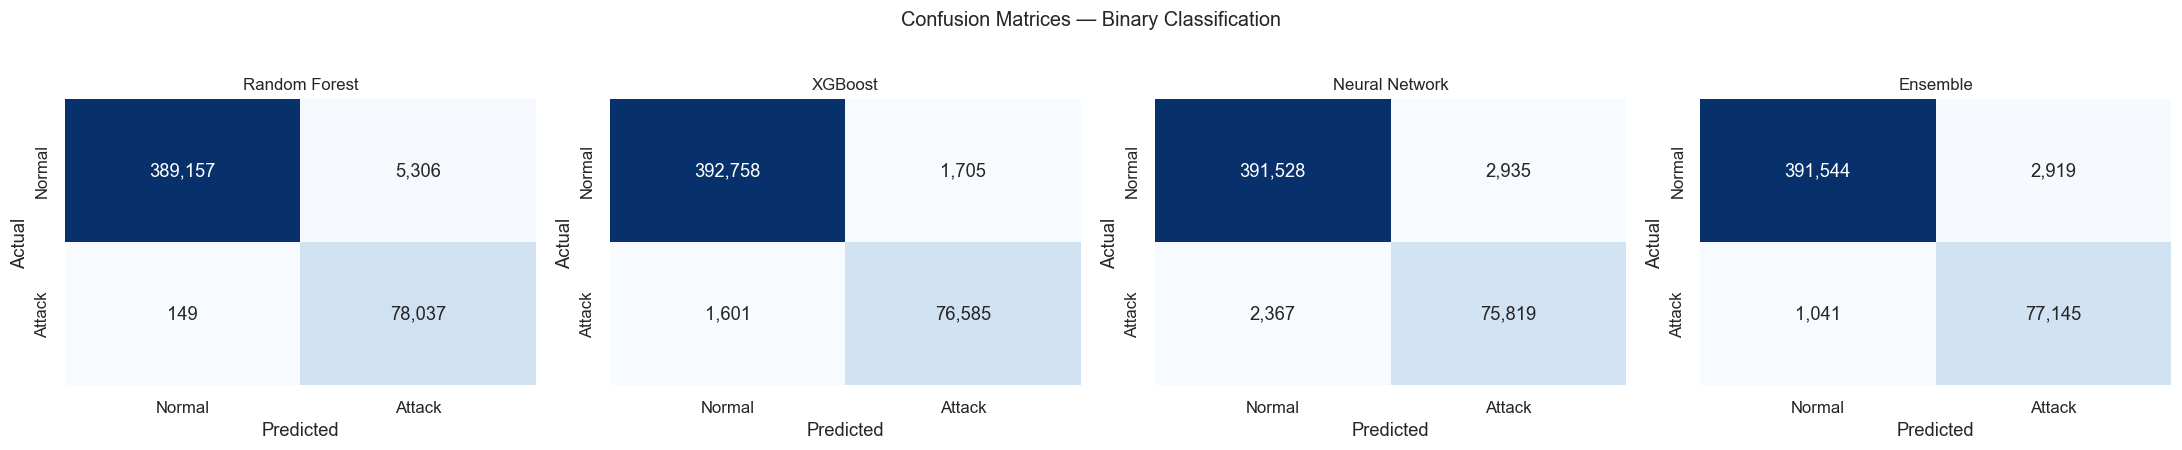

In [53]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
model_preds = [
    ('Random Forest',  (p_rf[:,1]  >= 0.5).astype(int)),
    ('XGBoost',        (p_xgb[:,1] >= 0.5).astype(int)),
    ('Neural Network', (p_mlp[:,1] >= 0.5).astype(int)),
    ('Ensemble',       ens_pred),
]
for ax, (name, pred) in zip(axes, model_preds):
    cm = confusion_matrix(yb_te, pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'],
                cbar=False)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — Binary Classification', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices_binary.png'), bbox_inches='tight')
plt.show()

In [54]:
print('=== Ensemble Binary Classification Report ===')
print(classification_report(yb_te, ens_pred, target_names=['Normal', 'Attack']))

=== Ensemble Binary Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    394463
      Attack       0.96      0.99      0.97     78186

    accuracy                           0.99    472649
   macro avg       0.98      0.99      0.98    472649
weighted avg       0.99      0.99      0.99    472649



## 7. Multi-Class Classification — Attack Category Detection

In [55]:
pm_rf  = rf_mc.predict_proba(X_test)
pm_xgb = xgb_mc.predict_proba(X_test)
pm_mlp = mlp_mc.predict_proba(X_te_sc)

mc_results = {}
for name, proba in [('Random Forest', pm_rf), ('XGBoost', pm_xgb), ('Neural Network', pm_mlp)]:
    pred = np.argmax(proba, axis=1)
    mc_results[name] = {
        'Accuracy': accuracy_score(ym_te, pred),
        'F1 (weighted)': f1_score(ym_te, pred, average='weighted'),
        'AUC-ROC (OvR)': roc_auc_score(ym_te, proba, multi_class='ovr', average='weighted'),
    }

ens_mc_prob = (pm_rf + pm_xgb + pm_mlp) / 3.0
ens_mc_pred = np.argmax(ens_mc_prob, axis=1)
mc_results['Ensemble (RF+XGB+MLP)'] = {
    'Accuracy': accuracy_score(ym_te, ens_mc_pred),
    'F1 (weighted)': f1_score(ym_te, ens_mc_pred, average='weighted'),
    'AUC-ROC (OvR)': roc_auc_score(ym_te, ens_mc_prob, multi_class='ovr', average='weighted'),
}

mc_df = pd.DataFrame(mc_results).T.round(4)
mc_df.index.name = 'Model'
print('Multi-Class Classification Results:')
print(mc_df.to_string())

Multi-Class Classification Results:
                       Accuracy  F1 (weighted)  AUC-ROC (OvR)
Model                                                        
Random Forest            0.9808         0.9840         0.9995
XGBoost                  0.9886         0.9885         0.9997
Neural Network           0.9836         0.9826         0.9991
Ensemble (RF+XGB+MLP)    0.9875         0.9884         0.9996


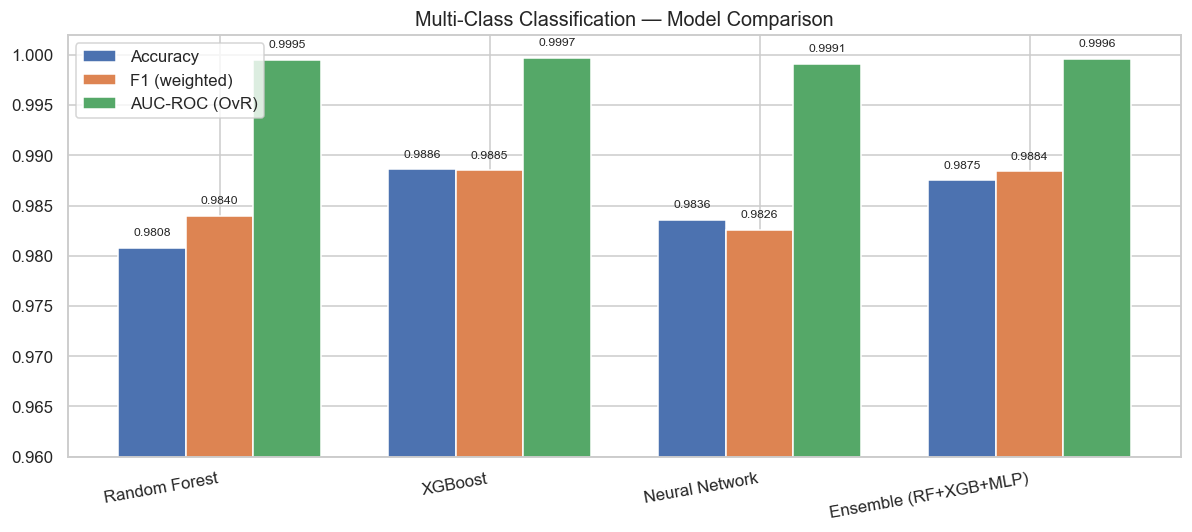

In [56]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(mc_df))
for i, (metric, color) in enumerate(zip(['Accuracy','F1 (weighted)','AUC-ROC (OvR)'], colors)):
    bars = ax.bar(x + i*w, mc_df[metric], w, label=metric, color=color, edgecolor='white')
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
                f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x + w)
ax.set_xticklabels(mc_df.index, rotation=10, ha='right')
ax.set_ylim(0.96, 1.002)
ax.set_title('Multi-Class Classification — Model Comparison', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'multiclass_model_comparison.png'), bbox_inches='tight')
plt.show()

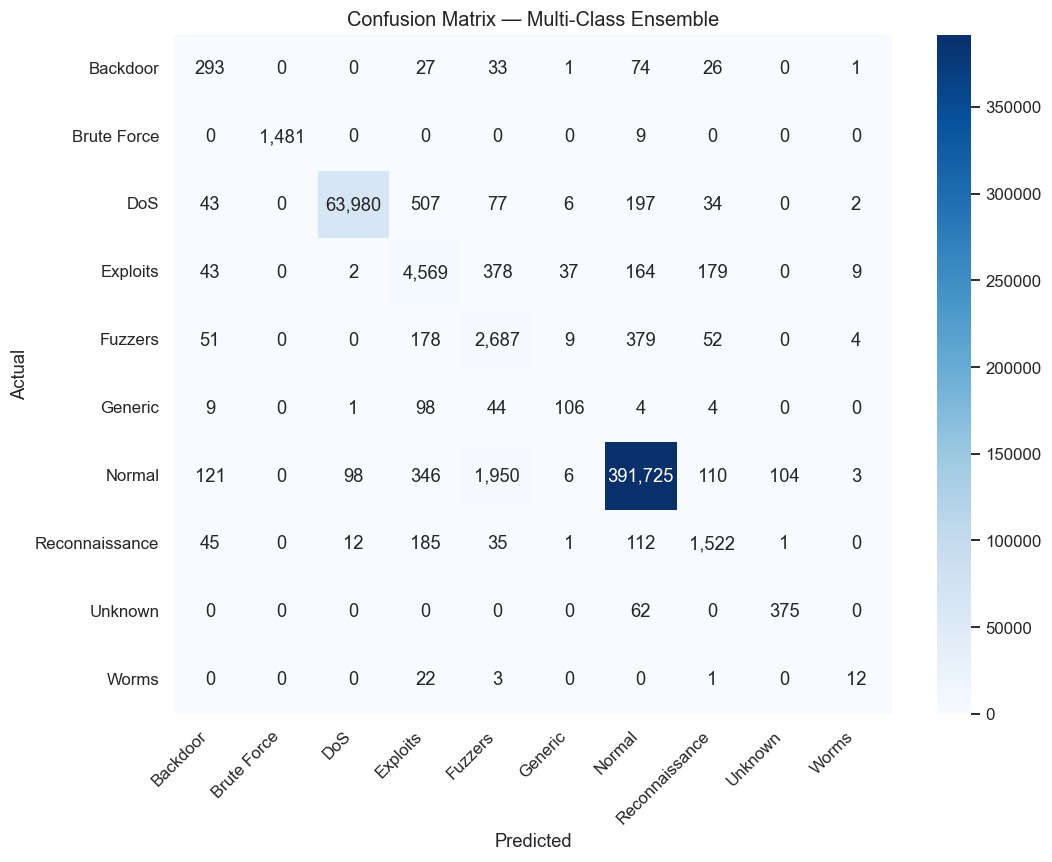

In [57]:
fig, ax = plt.subplots(figsize=(10, 8))
cm_mc = confusion_matrix(ym_te, ens_mc_pred)
sns.heatmap(cm_mc, annot=True, fmt=',d', cmap='Blues', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_title('Confusion Matrix — Multi-Class Ensemble', fontsize=13)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_multiclass.png'), bbox_inches='tight')
plt.show()

In [58]:
print('=== Ensemble Multi-Class Classification Report ===')
print(classification_report(ym_te, ens_mc_pred, target_names=le.classes_))

=== Ensemble Multi-Class Classification Report ===
                precision    recall  f1-score   support

      Backdoor       0.48      0.64      0.55       455
   Brute Force       1.00      0.99      1.00      1490
           DoS       1.00      0.99      0.99     64846
      Exploits       0.77      0.85      0.81      5381
       Fuzzers       0.52      0.80      0.63      3360
       Generic       0.64      0.40      0.49       266
        Normal       1.00      0.99      1.00    394463
Reconnaissance       0.79      0.80      0.79      1913
       Unknown       0.78      0.86      0.82       437
         Worms       0.39      0.32      0.35        38

      accuracy                           0.99    472649
     macro avg       0.74      0.76      0.74    472649
  weighted avg       0.99      0.99      0.99    472649



## 8. Feature Importance (Random Forest & XGBoost)

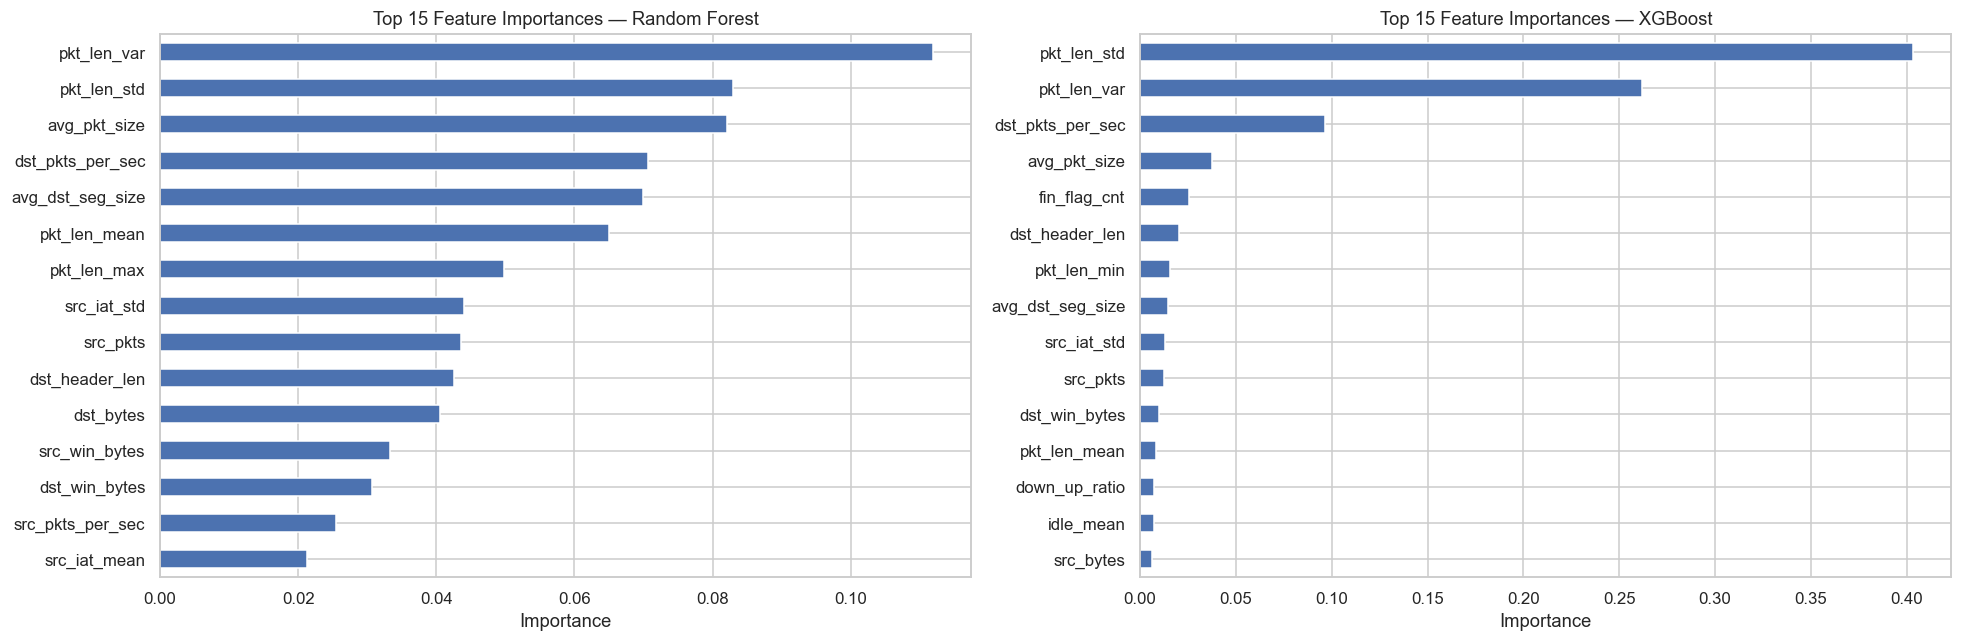

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, model, name in [
    (axes[0], rf_bin,  'Random Forest'),
    (axes[1], xgb_bin, 'XGBoost'),
]:
    importances = pd.Series(model.feature_importances_, index=FEATURE_COLS)
    top15 = importances.sort_values(ascending=True).tail(15)
    top15.plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Top 15 Feature Importances — {name}', fontsize=12)
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importances.png'), bbox_inches='tight')
plt.show()

## 9. Final Summary

In [60]:
print('=' * 55)
print('  IDS ENSEMBLE MODEL — FINAL RESULTS SUMMARY')
print('=' * 55)
print(f'  Dataset        : CIC-IDS2017 + UNSW-NB15')
print(f'  Total samples  : {len(merged):,}')
print(f'  Features       : {len(FEATURE_COLS)}')
print(f'  Train/Test     : 80% / 20%')
print()
print('  BINARY (Normal vs Attack)')
ens_bin = results['Ensemble (RF+XGB+MLP)']
print(f'    Accuracy : {ens_bin["Accuracy"]:.4f}')
print(f'    F1 Score : {ens_bin["F1 (weighted)"]:.4f}')
print(f'    AUC-ROC  : {ens_bin["AUC-ROC"]:.4f}')
print()
print('  MULTI-CLASS (Attack Category)')
ens_mc = mc_results['Ensemble (RF+XGB+MLP)']
print(f'    Accuracy : {ens_mc["Accuracy"]:.4f}')
print(f'    F1 Score : {ens_mc["F1 (weighted)"]:.4f}')
print(f'    AUC-ROC  : {ens_mc["AUC-ROC (OvR)"]:.4f}')
print()
print('  Models saved in: Ensemble_Output/')
print('=' * 55)

  IDS ENSEMBLE MODEL — FINAL RESULTS SUMMARY
  Dataset        : CIC-IDS2017 + UNSW-NB15
  Total samples  : 2,363,245
  Features       : 41
  Train/Test     : 80% / 20%

  BINARY (Normal vs Attack)
    Accuracy : 0.9916
    F1 Score : 0.9917
    AUC-ROC  : 0.9997

  MULTI-CLASS (Attack Category)
    Accuracy : 0.9875
    F1 Score : 0.9884
    AUC-ROC  : 0.9996

  Models saved in: Ensemble_Output/


## 10. Inference Demo — Predict on New Samples

In [61]:
def predict_ensemble(X_new: pd.DataFrame) -> pd.DataFrame:
    """Predict binary label + attack category for new network flow samples."""
    X_raw = X_new[FEATURE_COLS].replace([np.inf,-np.inf], np.nan).fillna(0)
    X_sc  = scaler.transform(X_raw)

    # Binary
    p_bin = (
        rf_bin.predict_proba(X_raw)[:,1] +
        xgb_bin.predict_proba(X_raw)[:,1] +
        mlp_bin.predict_proba(X_sc)[:,1]
    ) / 3.0

    # Multi-class
    p_mc = (
        rf_mc.predict_proba(X_raw) +
        xgb_mc.predict_proba(X_raw) +
        mlp_mc.predict_proba(X_sc)
    ) / 3.0

    return pd.DataFrame({
        'binary_label':    (p_bin >= 0.5).astype(int),
        'attack_category': le.inverse_transform(np.argmax(p_mc, axis=1)),
        'attack_confidence': p_bin.round(4),
    })

# Demo: run on 10 random test samples
sample_idx = np.random.choice(len(X_test), 10, replace=False)
X_demo = X_test.iloc[sample_idx].reset_index(drop=True)
y_demo_true_bin   = yb_te[sample_idx]
y_demo_true_cat   = le.inverse_transform(ym_te[sample_idx])

preds = predict_ensemble(X_demo)
preds['true_label']    = y_demo_true_bin
preds['true_category'] = y_demo_true_cat
preds['correct']       = preds['binary_label'] == preds['true_label']
print(preds.to_string(index=False))

 binary_label attack_category  attack_confidence  true_label true_category  correct
            0          Normal             0.0000           0        Normal     True
            1         Fuzzers             0.9501           1       Fuzzers     True
            0          Normal             0.0000           0        Normal     True
            0          Normal             0.0000           0        Normal     True
            1          Normal             0.5089           1      Exploits     True
            0          Normal             0.0088           0        Normal     True
            0          Normal             0.0206           0        Normal     True
            0          Normal             0.0000           0        Normal     True
            0          Normal             0.0000           0        Normal     True
            0          Normal             0.0035           0        Normal     True


In [62]:
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

OUTPUT_DIR = 'Ensemble_Output'
RANDOM_STATE = 42

FEATURE_COLS = [
    'duration','src_pkts','dst_pkts','src_bytes','dst_bytes',
    'flow_bytes_per_sec','flow_pkts_per_sec','flow_iat_mean',
    'src_iat_mean','dst_iat_mean','src_iat_std','dst_iat_std',
    'src_psh_flags','dst_psh_flags','src_urg_flags','dst_urg_flags',
    'src_header_len','dst_header_len','src_pkts_per_sec','dst_pkts_per_sec',
    'pkt_len_min','pkt_len_max','pkt_len_mean','pkt_len_std','pkt_len_var',
    'fin_flag_cnt','syn_flag_cnt','rst_flag_cnt','psh_flag_cnt',
    'ack_flag_cnt','urg_flag_cnt','down_up_ratio','avg_pkt_size',
    'avg_src_seg_size','avg_dst_seg_size','src_win_bytes','dst_win_bytes',
    'idle_mean','idle_std','idle_max','idle_min',
]

# Load models
rf_bin  = joblib.load(f'{OUTPUT_DIR}/rf_binary.pkl')
xgb_bin = joblib.load(f'{OUTPUT_DIR}/xgb_binary.pkl')
mlp_bin = joblib.load(f'{OUTPUT_DIR}/mlp_binary.pkl')
rf_mc   = joblib.load(f'{OUTPUT_DIR}/rf_multiclass.pkl')
xgb_mc  = joblib.load(f'{OUTPUT_DIR}/xgb_multiclass.pkl')
mlp_mc  = joblib.load(f'{OUTPUT_DIR}/mlp_multiclass.pkl')
scaler  = joblib.load(f'{OUTPUT_DIR}/scaler.pkl')
le      = joblib.load(f'{OUTPUT_DIR}/label_encoder.pkl')

# Load dataset and recreate the same test split
df = pd.read_csv('Merged_Output/merged_ids_dataset.csv', low_memory=False)
X = df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0)
y_bin   = df['label'].astype(int).values
y_multi = le.transform(df['attack_category'].astype(str))

_, X_test, _, yb_te, _, ym_te = train_test_split(
    X, y_bin, y_multi, test_size=0.20,
    random_state=RANDOM_STATE, stratify=y_bin
)
X_te_sc = scaler.transform(X_test)

def predict_ensemble(X_new):
    X_raw = X_new[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0)
    X_sc  = scaler.transform(X_raw)
    p_bin = (rf_bin.predict_proba(X_raw)[:,1] +
             xgb_bin.predict_proba(X_raw)[:,1] +
             mlp_bin.predict_proba(X_sc)[:,1]) / 3.0
    p_mc  = (rf_mc.predict_proba(X_raw) +
             xgb_mc.predict_proba(X_raw) +
             mlp_mc.predict_proba(X_sc)) / 3.0
    return pd.DataFrame({
        'binary_label':      (p_bin >= 0.5).astype(int),
        'attack_category':   le.inverse_transform(np.argmax(p_mc, axis=1)),
        'attack_confidence': p_bin.round(4),
    })

print("Ready. X_test has", len(X_test), "samples.")


Ready. X_test has 472649 samples.


In [63]:
import numpy as np

# Stratified sample — picks from each attack category proportionally
from collections import defaultdict

attack_idx = np.where(yb_te == 1)[0]
normal_idx = np.where(yb_te == 0)[0]

# 10 normals + 10 attacks, all random each run
picked = np.concatenate([
    np.random.choice(normal_idx, 10, replace=False),
    np.random.choice(attack_idx, 10, replace=False),
])
np.random.shuffle(picked)

sample = X_test.iloc[picked].reset_index(drop=True)
result = predict_ensemble(sample)
result['true_label']    = yb_te[picked]
result['true_category'] = le.inverse_transform(ym_te[picked])
result['correct']       = result['binary_label'] == result['true_label']

print(result.to_string(index=False))
print(f"\nAccuracy on 20 samples : {result['correct'].mean()*100:.1f}%")


 binary_label attack_category  attack_confidence  true_label  true_category  correct
            1             DoS             1.0000           1            DoS     True
            0          Normal             0.0026           0         Normal     True
            1             DoS             1.0000           1            DoS     True
            0          Normal             0.0000           0         Normal     True
            0          Normal             0.0000           0         Normal     True
            1             DoS             0.9998           1            DoS     True
            0          Normal             0.0000           0         Normal     True
            0          Normal             0.0000           0         Normal     True
            0          Normal             0.0000           0         Normal     True
            1             DoS             0.9700           1            DoS     True
            1  Reconnaissance             0.8348           1 Reco